# 04 · Predicting whether a complaint will be upheld

**Business question:** from what we know when a complaint arrives (the firm, product area and what it's about),
can we estimate how likely the ombudsman is to find in the customer's favour?

A bank could use this to prioritise complaints that are likely to be lost, and settle them earlier and more cheaply.

ML approach (classification, lessons 8 and 10–12 of ML-For-Beginners):
- **Target:** `upheld` (1 = customer wins, 0 = not upheld). Only ~27% are upheld, so the classes are **imbalanced**.
- **Baseline:** always predict the majority class. Any real model must beat this.
- **Models:** Logistic Regression (text + categories) and Random Forest (categories only)
- **Evaluation:** 5-fold stratified cross-validation, ROC-AUC and balanced accuracy, then a hold-out test set

In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make "src" importable when the notebook runs from the notebooks/ folder
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

FIG_DIR = ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams.update({"figure.dpi": 110, "axes.titleweight": "bold"})
pd.set_option("display.max_colwidth", 120)

In [2]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (classification_report, ConfusionMatrixDisplay, RocCurveDisplay,
                             roc_auc_score, balanced_accuracy_score)

df = pd.read_csv(ROOT / "data" / "processed" / "decisions_clean.csv")
print(df["upheld"].value_counts(normalize=True).rename({0: "not upheld", 1: "upheld"}).round(3))

upheld
not upheld    0.731
upheld        0.269
Name: proportion, dtype: float64


## 1. Features
- **Categorical:** `theme`, `firm_type`, `sector`, and `firm_group` (only the groups with ≥15 decisions; the rest become "Other" so the model isn't fitting to a single case)
- **Text:** TF-IDF of the complaint sentence

I deliberately **don't** use anything that's only known after the decision (e.g. the PDF length), which would be *data leakage*.

In [3]:
big_groups = df["firm_group"].value_counts().loc[lambda s: s >= 15].index
df["firm_group_top"] = df["firm_group"].where(df["firm_group"].isin(big_groups), "Other")

cat_cols = ["theme", "firm_type", "sector", "firm_group_top"]
X = df[cat_cols + ["complaint_text"]]
y = df["upheld"]

# Hold out 25% as a final test set the models never see during tuning
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)
print(len(X_train), "train /", len(X_test), "test")

720 train / 240 test


In [4]:
text_vec = TfidfVectorizer(lowercase=True, stop_words="english", ngram_range=(1, 2), min_df=3, max_df=0.5,
                           sublinear_tf=True)
onehot = OneHotEncoder(handle_unknown="ignore")

models = {
    "Baseline (majority class)": Pipeline([
        ("prep", ColumnTransformer([("cat", onehot, cat_cols)])),
        ("clf", DummyClassifier(strategy="most_frequent"))]),
    "Logistic Regression (categories only)": Pipeline([
        ("prep", ColumnTransformer([("cat", onehot, cat_cols)])),
        ("clf", LogisticRegression(class_weight="balanced", max_iter=2000, C=1.0))]),
    "Logistic Regression (categories + text)": Pipeline([
        ("prep", ColumnTransformer([("cat", onehot, cat_cols), ("txt", text_vec, "complaint_text")])),
        ("clf", LogisticRegression(class_weight="balanced", max_iter=2000, C=0.5))]),
    "Random Forest (categories only)": Pipeline([
        ("prep", ColumnTransformer([("cat", onehot, cat_cols)])),
        ("clf", RandomForestClassifier(n_estimators=400, min_samples_leaf=5, class_weight="balanced",
                                       random_state=42))]),
}

## 2. Cross-validation on the training set
- **ROC-AUC**: the chance the model ranks a random upheld complaint above a random not-upheld one. 0.5 = coin flip, 1.0 = perfect.
- **Balanced accuracy**: the average of the accuracy on each class. Plain accuracy is misleading here: the baseline gets 73% by never predicting "upheld".

In [5]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rows = []
for name, pipe in models.items():
    res = cross_validate(pipe, X_train, y_train, cv=cv, scoring=["roc_auc", "balanced_accuracy", "accuracy"])
    rows.append({"model": name,
                 "ROC-AUC": res["test_roc_auc"].mean(), "ROC-AUC sd": res["test_roc_auc"].std(),
                 "balanced accuracy": res["test_balanced_accuracy"].mean(),
                 "accuracy": res["test_accuracy"].mean()})
cv_results = pd.DataFrame(rows).set_index("model")
cv_results.style.format("{:.3f}")

,ROC-AUC,ROC-AUC sd,balanced accuracy,accuracy
model,,,,
Baseline (majority class),0.500,0.000,0.500,0.731
Logistic Regression (categories only),0.564,0.044,0.553,0.600
Logistic Regression (categories + text),0.595,0.055,0.573,0.635
Random Forest (categories only),0.576,0.045,0.575,0.642


## 3. Final check on the untouched test set
I take the best cross-validated model and evaluate it once on the 25% hold-out.

In [6]:
best_name = cv_results["ROC-AUC"].idxmax()
best = models[best_name].fit(X_train, y_train)
proba = best.predict_proba(X_test)[:, 1]
pred = best.predict(X_test)
print("Best model:", best_name)
print(f"Test ROC-AUC: {roc_auc_score(y_test, proba):.3f} | balanced accuracy: {balanced_accuracy_score(y_test, pred):.3f}\n")
print(classification_report(y_test, pred, target_names=["not upheld", "upheld"]))

Best model: Logistic Regression (categories + text)
Test ROC-AUC: 0.630 | balanced accuracy: 0.592

              precision    recall  f1-score   support

  not upheld       0.79      0.72      0.75       176
      upheld       0.38      0.47      0.42        64

    accuracy                           0.65       240
   macro avg       0.58      0.59      0.58       240
weighted avg       0.68      0.65      0.66       240



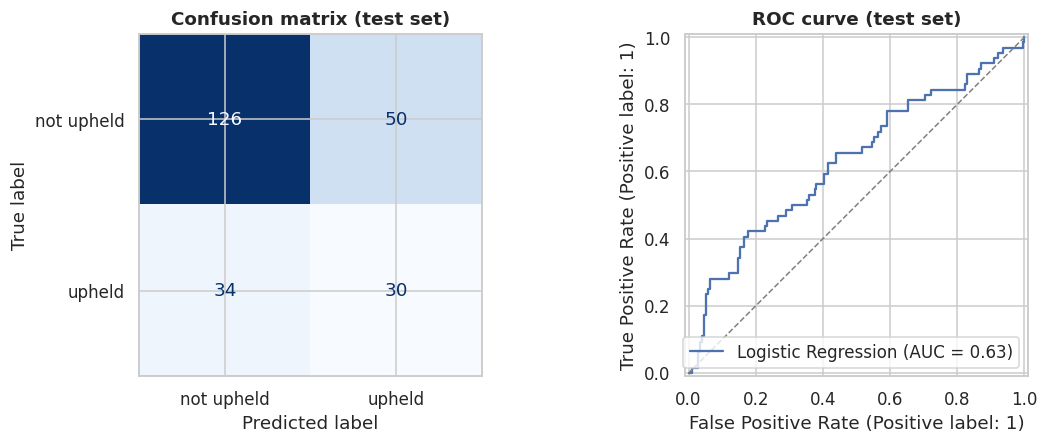

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
ConfusionMatrixDisplay.from_predictions(y_test, pred, display_labels=["not upheld", "upheld"], cmap="Blues",
                                        colorbar=False, ax=axes[0])
axes[0].set_title("Confusion matrix (test set)")
RocCurveDisplay.from_predictions(y_test, proba, ax=axes[1], name=best_name.split(" (")[0])
axes[1].plot([0, 1], [0, 1], ls="--", color="grey", lw=1)
axes[1].set_title("ROC curve (test set)")
plt.tight_layout(); plt.savefig(FIG_DIR / "07_model_evaluation.png"); plt.show()

## 4. What drives the prediction?
For logistic regression, each feature gets a coefficient. Positive = pushes towards "upheld", negative = towards "not upheld".
This is what makes logistic regression a good choice for a business audience: it can be explained.

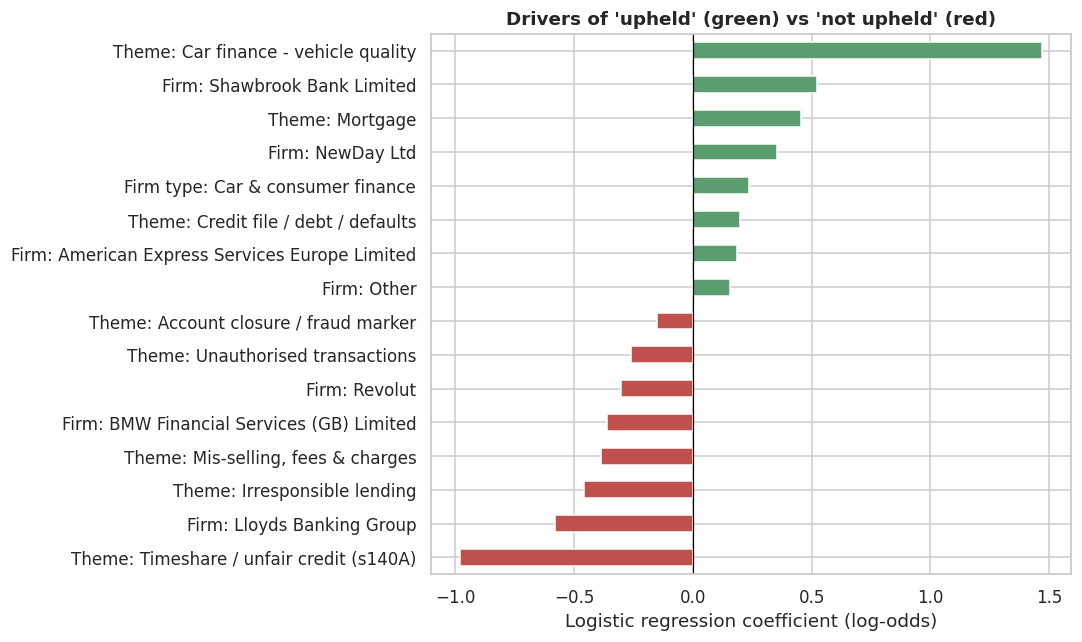

In [8]:
explain = models["Logistic Regression (categories only)"].fit(X_train, y_train)
names = explain.named_steps["prep"].get_feature_names_out()
coefs = pd.Series(explain.named_steps["clf"].coef_[0], index=names)
labels = {"cat__theme_": "Theme: ", "cat__firm_type_": "Firm type: ", "cat__sector_": "Sector: ",
          "cat__firm_group_top_": "Firm: "}
coefs.index = coefs.index.to_series().replace(labels, regex=True).values
top = pd.concat([coefs.nlargest(8), coefs.nsmallest(8)]).sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
top.plot.barh(color=np.where(top > 0, "#5a9e6f", "#c0504d"), ax=ax)
ax.axvline(0, color="black", lw=0.8)
ax.set(title="Drivers of 'upheld' (green) vs 'not upheld' (red)",
       xlabel="Logistic regression coefficient (log-odds)")
plt.tight_layout(); plt.savefig(FIG_DIR / "08_feature_importance.png"); plt.show()

## Honest conclusions
- The models beat the baseline, but only **modestly**. That's expected: the ombudsman decides each case on its individual facts,
  and we only have the first sentence of each summary.
- **The complaint theme is the strongest signal**; which bank it is adds relatively little.
- Adding the complaint text gives a **small lift** (cross-validated ROC-AUC ≈ 0.60 vs ≈ 0.56 for categories only), but with more variation between folds. On the hold-out test set the best model reaches ROC-AUC ≈ 0.63.
- In practice I'd present the **categories-only logistic regression** to the business (it's easy to explain) and keep the text model as the higher-scoring version.
- **How I'd improve it:** download the full decision PDFs (`pdf_url` column) for richer text, collect several thousand decisions,
  and add features such as the amount lost or whether a claims firm represented the customer.

In an interview, being clear about these limits is more convincing than claiming high accuracy.